In [12]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
import imageio
from sklearn.datasets import make_moons
import math

from coupling import mini_batch_coupling, greedy_coupling, sinkhorm_coupling
from flow_model import MLP
from sampler import GaussSampler, CheckerBoardSampler
from draw import DrawFlow, DrawSample
from gen_path import get_xt


In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device=device)

In [14]:
def sample_source(size, **args):
    # return GaussSampler.sample_symmetric_gauss(size, n_gauss=2, center=[-5.0, 0.0], distance=5.0,var=0.5)
    return GaussSampler.sample_symmetric_gauss(size, n_gauss=8,distance=5, var=0.16)
def sample_target(size, **args):
    # MOG
    # return GaussSampler.sample_symmetric_gauss(size, 2, center=[5.0, 0.0], distance=5.0, var=0.5)
    # MAKE MOON
    X, y = make_moons(n_samples=size, noise=0.04)
    X = X * 1.5
    X[y == 1, 1] -= 0.8
    center = X.mean(axis=0)
    X = X - center
    return torch.Tensor(X)
    # Checkerboard
    # return CheckerBoardSampler.sample_checkerboard_region(size, max_x=4, max_y=4, min_x=-4, min_y=-4, tiles=4)

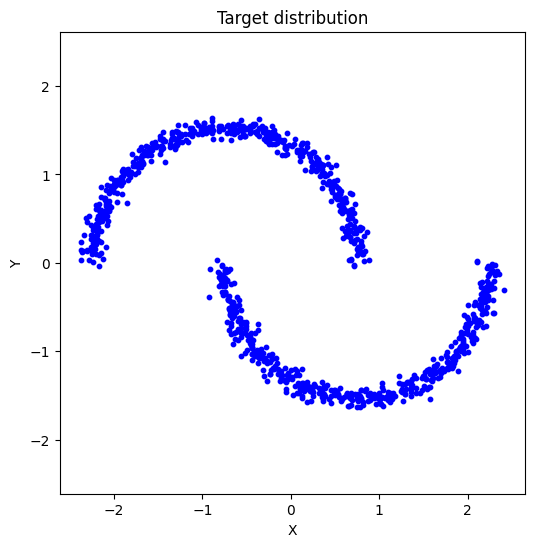

In [15]:
# DrawSample.draw_samples_comparison(sample_source(256).cpu(), sample_target(256).cpu())
DrawSample.draw_samples(sample_target(1024).cpu(), title="Target distribution")

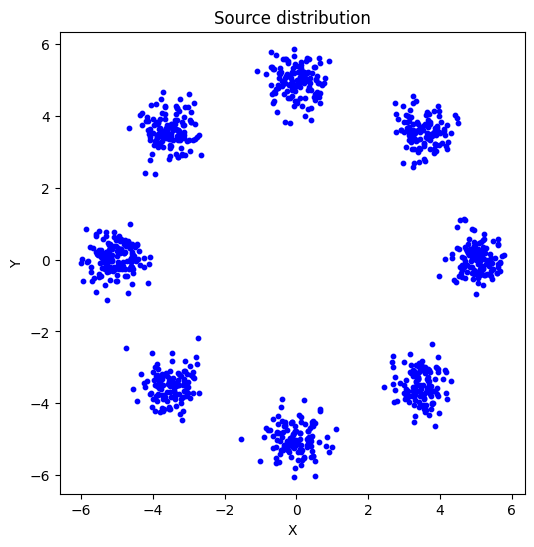

In [16]:
DrawSample.draw_samples(sample_source(1024).cpu(), title="Source distribution")

In [17]:
flow  = MLP(hidden_dim=256, layers=4)

optimizer = torch.optim.Adam(flow.parameters(), lr = 1e-3)
loss_fn =  nn.MSELoss()

In [18]:
loss_history = []

epochs = 3000
batch = 512
des = sample_target(8192).to(device=device)
acc_loss = 0
for _ in range(epochs):
    x_1 = des[torch.randint(0, des.size(0), (batch,))]  
    # x_1 = sample_target(batch).to(device=device) 
    x_0 = sample_source(batch).to(device=device)
    # print(x_1.shape, x_0.shape)
    x1 = x_1[sinkhorm_coupling(x_0, x_1)]
    
    t = torch.rand(batch, 1)
    x_t = get_xt(x_0, x_1, t).to(device=device)
    u_t = x_1 - x_0
    
    v_pred = flow(x_t, t)
    loss = loss_fn(v_pred.flatten(), u_t.flatten())
    # print(loss)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    acc_loss += loss.item()
    # acc_loss.append(loss.item())
    if ( (_ + 1) % 100 == 0):
        # optimizer.zero_grad()
        # optimizer.step()
        avg_loss = acc_loss / 100
        loss_history.append(avg_loss)
        print(f"Epoch {_ + 1}, Loss: {avg_loss:.4f}")
        acc_loss = 0

Epoch 100, Loss: 7.0770
Epoch 200, Loss: 6.1975
Epoch 300, Loss: 5.6291
Epoch 400, Loss: 5.4671
Epoch 500, Loss: 5.2584
Epoch 600, Loss: 5.1840
Epoch 700, Loss: 5.0989
Epoch 800, Loss: 4.9138
Epoch 900, Loss: 4.8612
Epoch 1000, Loss: 4.8804
Epoch 1100, Loss: 4.7823
Epoch 1200, Loss: 4.7678
Epoch 1300, Loss: 4.6841
Epoch 1400, Loss: 4.7246
Epoch 1500, Loss: 4.7190
Epoch 1600, Loss: 4.6114
Epoch 1700, Loss: 4.5998
Epoch 1800, Loss: 4.5664
Epoch 1900, Loss: 4.5945
Epoch 2000, Loss: 4.5814
Epoch 2100, Loss: 4.5648
Epoch 2200, Loss: 4.5180
Epoch 2300, Loss: 4.4718
Epoch 2400, Loss: 4.4640
Epoch 2500, Loss: 4.4755
Epoch 2600, Loss: 4.4431
Epoch 2700, Loss: 4.4219
Epoch 2800, Loss: 4.4312
Epoch 2900, Loss: 4.3978
Epoch 3000, Loss: 4.3333


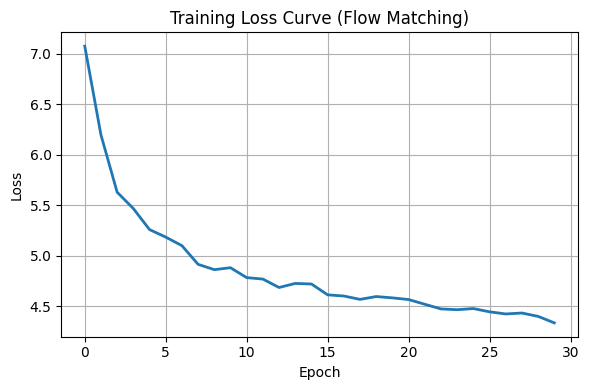

In [19]:
plt.figure(figsize=(6, 4))

# Giả sử loss_history có dạng: 1 giá trị cho mỗi 100 epochs
epochs_num = [i  for i in range(len(loss_history))]

plt.plot(epochs_num, loss_history, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve (Flow Matching)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [20]:
steps = 100
time_steps = torch.linspace(0, 1.0, steps + 1)

x_0 = sample_source(128)
# print(x_0)

t = 0.0


In [21]:
results = []
# results.append(x)

# inference
# model = MLP(hidden_dim=256, layers=4)
# model.load_state_dict(torch.load("independent_coupling_flow.pth"))
x = x_0
flow.eval()
with torch.no_grad():
    for i in range(steps):
        # t = torch.full((x.shape[0], 1), time_steps[i].item())
        # x = x + flow(x, t) * (time_steps[i+1] - time_steps[i])
        
        x = flow.step(x, time_steps[i], time_steps[i+1])
        results.append(x)

# results.append(sample_target(128))
# steps = 1.0/256
# results = solver.sample(x_0, step_size=1.0/steps,  time_grid=time_grid, return_intermediates=True)

# print("Sampled x_1:", results[:-1])



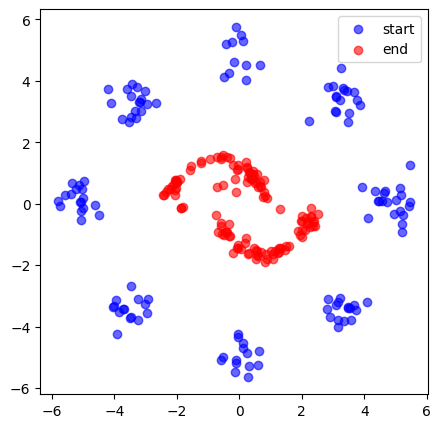

In [22]:
from draw import DrawSample

DrawSample.draw_samples_comparison(results[0].cpu(), results[-1].cpu(),title="", title1="start", title2="end")

In [23]:
# first = sample_source(1028)
# last = sample_target(1028)
# # mini_batch_coupling(first, last, mini_batch_size=32)
# last = last[mini_batch_coupling(first, last)]

# first = first.detach().cpu().numpy()
# last = last.detach().cpu().numpy()

# plt.figure(figsize=(6, 6))

# # Vẽ điểm
# plt.scatter(first[:, 0], first[:, 1], label='First', color='blue')
# plt.scatter(last[:, 0], last[:, 1], label='Last', color='red')

# # Vẽ đường nối màu xanh nhạt giữa các điểm tương ứng
# for p1, p2 in zip(first, last):
#     plt.plot([p1[0], p2[0]], [p1[1], p2[1]],
#              color='lightblue', linewidth=1)

# plt.legend()
# plt.axis('equal')
# plt.show()

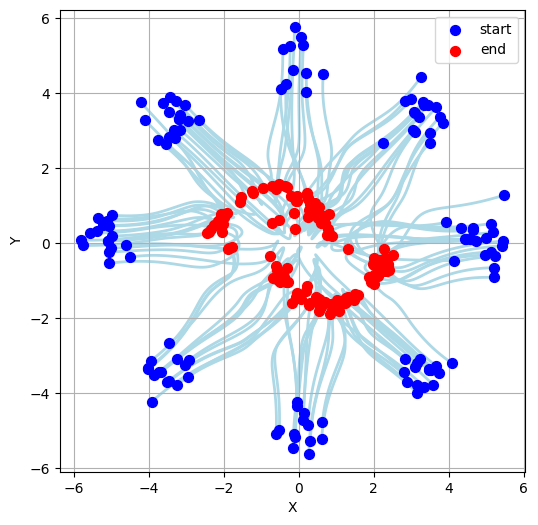

In [24]:
DrawFlow.draw_trajectory_from_results(results)

In [25]:
results_cpu_list = [r.detach().cpu().numpy() for r in results]
# print(results_cpu_list[0])
frames = []

for i, results_cpu in enumerate(results_cpu_list):
    fig, ax = plt.subplots(figsize=(5,5))
    
    ax.scatter(results_cpu[:,0], results_cpu[:,1], color='red', label=f'time step {i}')
    # ax.scatter(results_cpu[:,0], results_cpu[:,1], color='red', label=f'time step {i}')
    ax.legend()
    ax.set_title("ODE Sampling: Batch points over time")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True)
    ax.set_xlim([-6, 6])
    ax.set_ylim([-6, 6])
    
    # Lưu figure vào buffer
    fig.canvas.draw()
    w, h = fig.canvas.get_width_height()
    buf = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
    image = buf.reshape((h, w, 4))  # 4 kênh RGBA
    frames.append(image)
    plt.close(fig)

# Tạo GIF
imageio.mimsave('ode_sampling_batch.gif', frames, duration=0.01)

In [26]:
torch.save(flow.state_dict(), 'independent_coupling_flow.pth')